# SAM 3D Body with OpenVINO on Intel GPU

[SAM 3D Body](https://github.com/facebookresearch/sam-3d-body) is Meta's 3D human
pose and shape estimator: given an image and a person box it predicts 2D/3D
keypoints and a full parametric body mesh. This notebook takes the reference
PyTorch checkpoint, capable of running on CPU and Intel XPU as chosen, converts it to
OpenVINO IR (FP16 and INT8), runs the converted model on the Intel GPU,
and verifies that the outputs match — visually and by PCK@0.05 metric. This notebook demonstrates the SAM 3D Body model on a sample image downloaded from COCO dataset with OpenVINO as well as PyTorch (for a parity-check) and note that it does not measure the accuracy over COCO.

```
                 ┌────────────────────────┐
  Human image ──▶│ PyTorch  (CPU or XPU)  │──▶ keypoints + mesh + PCK   ← reference
                 └───────────┬────────────┘
                             │  torch.jit.trace ─▶ ov.convert_model
                             ▼
                 ┌────────────────────────┐
                 │  OpenVINO IR  FP16     │──▶ keypoints + mesh + PCK
                 │  OpenVINO IR  INT8     │──▶ keypoints + mesh + PCK
                 └────────────────────────┘
                          on Intel GPU
```

**Model pipeline** (per person):
`backbone (DINOv3 ViT-H/16+)` → `iterative decoder ×6 with MHR feedback` → `MHR mesh head` → `2D/3D keypoints`

The three helper modules live in this folder. The `sam_3d_body` model package is
fetched at runtime from the original SAM 3D Body's official
[GitHub repo](https://github.com/facebookresearch/sam-3d-body) and placed in this
same folder.

| File | Responsibility | Requires |
|---|---|---|
| [`sam3d_data.py`](sam3d_data.py) | sample loading, PCK scoring, skeleton + mesh rendering | NumPy, OpenCV, Matplotlib, pyrender, trimesh |
| [`sam3d_ov.py`](sam3d_ov.py) | OpenVINO IR runtime (iterative decoder loop) | OpenVINO, NumPy, OpenCV |
| [`sam3d_torch.py`](sam3d_torch.py) | PyTorch reference inference + PyTorch → OpenVINO export | PyTorch |

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

> Every section is re-runnable, and work that is already done (dependencies installed,
> package fetched, image downloaded, checkpoint fetched, IR exported) is **skipped
> automatically**.

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Configuration and device discovery](#Configuration-and-device-discovery)
- [Download the reference PyTorch model](#Download-the-reference-PyTorch-model)
- [Sample image and ground truth](#Sample-image-and-ground-truth)
- [PyTorch reference inference](#PyTorch-reference-inference)
- [Convert the model to OpenVINO IR](#Convert-the-model-to-OpenVINO-IR)
- [Run OpenVINO inference on Intel GPU](#Run-OpenVINO-inference-on-Intel-GPU)
- [Compare PyTorch and OpenVINO](#Compare-PyTorch-and-OpenVINO)
- [Summary](#Summary)

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/sam-3d-body/sam3dbody.ipynb" />

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

This notebook uses a plain **`venv`** created inside this folder (`.sam3dbody-nb-venv/`) — no conda,
no system-wide installs. If you have not created it yet:

```bash
cd notebooks   # this folder
python -m venv .sam3dbody-nb-venv
.sam3dbody-nb-venv/bin/pip install ipykernel
.sam3dbody-nb-venv/bin/python -m ipykernel install --user --name sam3dbody-nb-venv \
    --display-name "Python (sam3dbody-nb-venv)"
```

Select the **Python (sam3dbody-nb-venv)** kernel, then run the cells below: they
install every dependency **into that same `.sam3dbody-nb-venv`**, so there is nothing to set up
beforehand beyond creating it.

> **Where do the packages go?** Installation uses `pip_install()`, which runs
> `sys.executable -m pip install`. `sys.executable` is the interpreter running
> *this kernel*, so packages always land in the kernel's environment — not in
> the environment that launched the Jupyter server, and not in the system Python.
> The next cell prints that interpreter and warns if the kernel is **not**
> isolated, i.e. if installing here would modify your system Python.


In [1]:
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd() if (Path.cwd() / "sam3d_data.py").exists() else Path.cwd() / "notebooks"
LOCAL_VENV = NOTEBOOK_DIR / ".sam3dbody-nb-venv"

# A venv sets sys.prefix away from sys.base_prefix.
IS_ISOLATED = sys.prefix != sys.base_prefix
IS_LOCAL_VENV = Path(sys.prefix).resolve() == LOCAL_VENV.resolve()

print(f"Kernel Python : {sys.version.split()[0]}")
print(f"Interpreter   : {sys.executable}")
print(f"Environment   : {sys.prefix}")
print(f"Isolated env  : {'yes' if IS_ISOLATED else 'NO'}")
print(f"Local .sam3dbody-nb-venv   : {'yes' if IS_LOCAL_VENV else 'no'} (expected {LOCAL_VENV})")

if not IS_ISOLATED:
    print(
        "\nWARNING: this kernel is NOT running inside an isolated virtual environment,\n"
        "         so the next cell would install into your system Python.\n"
        "         Create a venv in this folder, register it as a kernel, then reselect it:\n\n"
        "           cd notebooks   # this folder\n"
        "           python -m venv .sam3dbody-nb-venv\n"
        "           .sam3dbody-nb-venv/bin/pip install ipykernel\n"
        "           .sam3dbody-nb-venv/bin/python -m ipykernel install --user --name sam3dbody-nb-venv \\\n"
        '                  --display-name "Python (sam3dbody-nb-venv)"\n'
    )

Kernel Python : 3.12.3
Interpreter   : /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/.sam3dbody-nb-venv/bin/python
Environment   : /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/.sam3dbody-nb-venv
Isolated env  : yes
Local .sam3dbody-nb-venv   : yes (expected /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/.sam3dbody-nb-venv)


In [2]:
import urllib.request

# `pip_install` runs `sys.executable -m pip install`, i.e. it always targets the
# interpreter printed above rather than whatever `pip` is first on $PATH.
if not Path("pip_helper.py").exists():
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/pip_helper.py",
        "pip_helper.py",
    )

# `notebook_utils` provides the device-selection widget and the telemetry
# hook that the openvino_notebooks CI checks look for.
if not Path("notebook_utils.py").exists():
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
        "notebook_utils.py",
    )

from pip_helper import pip_install

# PyTorch, Intel XPU build. These wheels also run on CPU, so one install covers
# both reference paths; pick TORCH_DEVICE below.
pip_install("-q", "--extra-index-url", "https://download.pytorch.org/whl/xpu", "torch>=2.6", "torchvision>=0.21")

# OpenVINO runtime + NNCF for INT8 weight-only compression.
pip_install("-q", "openvino>=2025.0", "nncf>=2.14")

# Imaging and numerics.
pip_install("-q", "opencv-python>=4.9", "scipy>=1.11", "Pillow>=10.0")

# Imported by the `sam_3d_body` package that is fetched at runtime.
pip_install(
    "-q",
    "timm>=1.0",
    "einops>=0.8",
    "omegaconf>=2.3",
    "hydra-core>=1.3",
    "pyrootutils>=1.0",
    "roma>=1.5",
    "yacs>=0.1.8",
    "pytorch-lightning>=2.0",
    "termcolor>=2.0",
)

# Visualization. pyrender renders the mesh offscreen through EGL.
pip_install("-q", "matplotlib>=3.8", "trimesh>=4.0", "pyrender>=0.1.45")

# Utilities.
pip_install("-q", "tqdm>=4.66", "huggingface_hub>=0.25", "braceexpand>=0.1.7", "ipywidgets>=8.1")

# NumPy last, so nothing above can quietly move it: NNCF caps it below 2.5 while
# matplotlib's contourpy needs at least 2.0, leaving one usable window.
pip_install("-q", "numpy>=2.0,<2.5")

print("\nDependencies installed into:", sys.prefix)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("sam3dbody.ipynb")


Dependencies installed into: /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/.sam3dbody-nb-venv


## Configuration and device discovery
[back to top ⬆️](#Table-of-contents:)

Imports the helper modules and reports which accelerators are visible to
**OpenVINO** and to **PyTorch**.

In [3]:
import time

# pyrender must pick a headless GL backend *before* it is first imported.
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

# --- Make the helper modules importable, wherever the notebook was launched ---
NOTEBOOK_DIR = Path.cwd() if (Path.cwd() / "sam3d_data.py").exists() else Path.cwd() / "notebooks"
sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
import openvino as ov
import torch

import sam3d_data as data
from sam3d_data import COCO17_TO_MHR70, compute_person_pck, free_memory, to_numpy
from sam3d_torch import find_repo_root, xpu_available

# The `sam_3d_body` package is Meta's code under the SAM License. Only that single
# package is fetched at runtime (a sparse clone of ~1 MB, not the whole repo) and
# placed in the root folder, beside these helpers — it is not redistributed with them.
MODEL_SRC = find_repo_root()
# Checkpoints and exported IRs live next to the notebook (see README).
DATA_ROOT = NOTEBOOK_DIR

print(f"Helpers   : {NOTEBOOK_DIR}")
print(f"Model src : {MODEL_SRC}")
print(f"Data root : {DATA_ROOT}")
print(f"NumPy     : {np.__version__}")
print(f"OpenVINO  : {ov.__version__}")
print(f"PyTorch   : {torch.__version__}")

# --- OpenVINO devices ---------------------------------------------------------
core = ov.Core()
print(f"\nOpenVINO devices: {core.available_devices}")
for dev in core.available_devices:
    try:
        print(f"  {dev:5s} -> {core.get_property(dev, 'FULL_DEVICE_NAME')}")
    except Exception:
        print(f"  {dev:5s} -> (name unavailable)")

# --- PyTorch devices ----------------------------------------------------------
print("\nPyTorch devices:")
print("  cpu   -> always available")
print(f"  xpu   -> {torch.xpu.get_device_name(0) if xpu_available() else 'not available'}")

# --- OpenVINO target device -----------------------------------------------------
# Interactive selector; its value drives OV_DEVICE in the CONFIG cell below.
from notebook_utils import device_widget

# Default to the Intel GPU when it is present, otherwise CPU (CI has no GPU).
device = device_widget(default="GPU" if "GPU" in core.available_devices else "CPU")

device

Helpers   : /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks
Model src : /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks
Data root : /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks
NumPy     : 2.4.6
OpenVINO  : 2026.4.0-22959-99c81491cc3-releases/2026/4
PyTorch   : 2.14.0+xpu

OpenVINO devices: ['CPU', 'GPU', 'NPU']
  CPU   -> Genuine Intel(R) 0000
  GPU   -> Intel(R) Arc(TM) B390 GPU (iGPU)
  NPU   -> Intel(R) AI Boost

PyTorch devices:
  cpu   -> always available
  xpu   -> Intel(R) Arc(TM) B390 GPU


Dropdown(description='Device:', index=1, options=('CPU', 'GPU', 'NPU', 'AUTO'), value='GPU')

In [4]:
# =============================== CONFIGURATION ===============================
# Reference PyTorch checkpoint (Hugging Face)
HF_REPO_ID = "facebook/sam-3d-body-dinov3"
CKPT_DIR = DATA_ROOT / "checkpoints" / "sam-3d-body-dinov3"
CHECKPOINT = CKPT_DIR / "model.ckpt"  # 2.0 GB
MHR_PATH = CKPT_DIR / "assets" / "mhr_model.pt"  # 664 MB

# Sample: the COCO image is downloaded on first use and
# cached here; its ground-truth annotation is embedded further down.
SAMPLE_DIR = DATA_ROOT / "sample_data"

# PyTorch reference backend: "cpu" (default, works everywhere) or "xpu" for an
# Intel GPU, but needs a torch+xpu build.
TORCH_DEVICE = "cpu"

# OpenVINO
OV_MODEL_ROOT = DATA_ROOT / "ov_models"  # <root>/{fp16,int8}/...
OV_DEVICE = device.value  # selected in the device widget above
PRECISIONS = ["fp16", "int8"]

# Evaluation
PCK_THRESHOLD = 0.05  # 5% of the GT bbox diagonal (paper protocol)

# Set True to re-export the OpenVINO IR even if it already exists (slow)
FORCE_EXPORT = False
# =============================================================================

if OV_DEVICE not in core.available_devices:
    print(f"WARNING: '{OV_DEVICE}' not found in {core.available_devices}; falling back to CPU.")
    OV_DEVICE = "CPU"

if TORCH_DEVICE == "xpu" and not xpu_available():
    print("WARNING: XPU requested but unavailable; the PyTorch stage will use the CPU.")
    TORCH_DEVICE = "cpu"

print(f"PyTorch reference device : {TORCH_DEVICE}")
print(f"OpenVINO target device   : {OV_DEVICE}")
print(f"Precisions to compare    : {PRECISIONS}")

RESULTS = {}  # backend name -> {person, keypoints, pck, latency_ms}

PyTorch reference device : cpu
OpenVINO target device   : GPU
Precisions to compare    : ['fp16', 'int8']


## Download the reference PyTorch model
[back to top ⬆️](#Table-of-contents:)

Pulls `facebook/sam-3d-body-dinov3` from Hugging Face (~2.7 GB total) — skipped
if the checkpoint is already on disk.

> The SAM 3D Body checkpoints are **gated**. Request access on the model page and
> authenticate once with `hf auth login` (or set `HF_TOKEN`) before running this cell.

In [5]:
def download_checkpoint():
    """Fetch the reference checkpoint from Hugging Face if it is not present."""
    if CHECKPOINT.exists() and MHR_PATH.exists():
        size_gb = (CHECKPOINT.stat().st_size + MHR_PATH.stat().st_size) / 1024**3
        print(f"[skip] Checkpoint already present at {CKPT_DIR}  ({size_gb:.1f} GB)")
        return

    from huggingface_hub import snapshot_download

    print(f"Downloading {HF_REPO_ID} -> {CKPT_DIR} ...")
    CKPT_DIR.mkdir(parents=True, exist_ok=True)
    snapshot_download(repo_id=HF_REPO_ID, local_dir=str(CKPT_DIR))
    print("Download complete.")


download_checkpoint()

for label, path in [("model.ckpt", CHECKPOINT), ("mhr_model.pt", MHR_PATH)]:
    status = f"{path.stat().st_size / 1024**2:8.1f} MB" if path.exists() else "MISSING"
    print(f"  {label:14s} {status}   {path}")

[skip] Checkpoint already present at /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/checkpoints/sam-3d-body-dinov3  (2.6 GB)
  model.ckpt       2011.4 MB   /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/checkpoints/sam-3d-body-dinov3/model.ckpt
  mhr_model.pt      663.9 MB   /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/checkpoints/sam-3d-body-dinov3/assets/mhr_model.pt


## Sample image and ground truth
[back to top ⬆️](#Table-of-contents:)

No sample data ships with this notebook. The demo image is downloaded from the
public [COCO val2017](https://cocodataset.org) servers on first use and cached in
`sample_data/`; its ground-truth annotation is small enough to embed directly in
the cell below.

The image has exactly one person with all 17 keypoints visible and a large
bounding box, which makes for a clean comparison. The ground-truth box is fed to
the model, so this measures pose accuracy without a detector in the loop.

> **Licensing.** COCO *annotations* are CC BY 4.0, so the annotation below is
> reproduced here with attribution. The COCO Consortium does **not** own the
> image copyright — image use is governed by the
> [Flickr Terms of Use](https://cocodataset.org/#termsofuse), which is why the
> image is fetched from COCO at runtime rather than redistributed.


Image      : /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/sample_data/000000368212.jpg  (478x640)
Source     : COCO val2017 (person_keypoints_val2017.json)
GT bbox    : x1=17 y1=43 x2=385 y2=608
Visible GT : 17/17 keypoints
Focal      : 798.8 px (image diagonal)


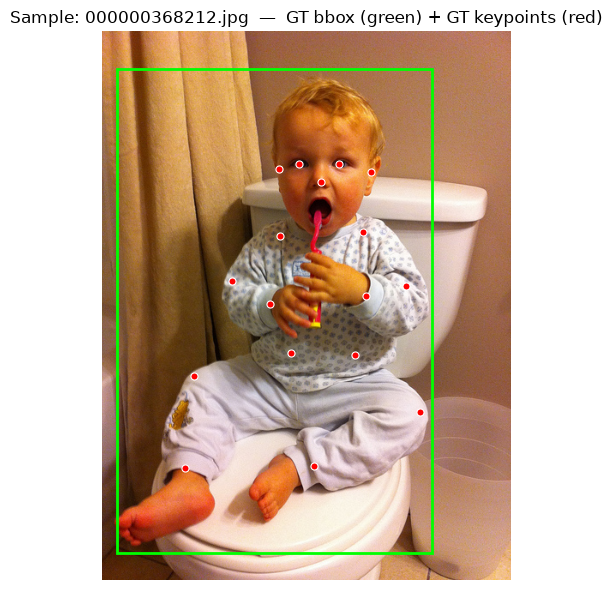

In [6]:
# Ground truth for COCO val2017 image 368212, from person_keypoints_val2017.json.
# COCO annotations are CC BY 4.0 (https://cocodataset.org/#termsofuse).
# `keypoints` is 17 x (x, y, visibility) in COCO order; `bbox` is [x, y, w, h].
SAMPLE_META = {
    "source": "COCO val2017 (person_keypoints_val2017.json)",
    "image_id": 368212,
    "file_name": "000000368212.jpg",
    "width": 478,
    "height": 640,
    # Primary: the official COCO server. Fallback mirror if it is unreachable.
    "image_urls": [
        "http://images.cocodataset.org/val2017/000000368212.jpg",
        "https://github.com/user-attachments/assets/b62b4b0e-a5b1-4fff-a81b-a4cceeb0d3b3",
    ],
    "annotation": {
        "id": 1221298,
        "image_id": 368212,
        "category_id": 1,
        "iscrowd": 0,
        "area": 97446.68745,
        "num_keypoints": 17,
        "bbox": [17.26, 43.15, 368.18, 565.21],
        "keypoints": [
            255,
            175,
            2,
            277,
            154,
            2,
            230,
            154,
            2,
            314,
            164,
            2,
            206,
            160,
            2,
            304,
            234,
            2,
            208,
            238,
            2,
            355,
            296,
            2,
            152,
            291,
            2,
            308,
            308,
            2,
            196,
            318,
            2,
            295,
            377,
            2,
            220,
            375,
            2,
            371,
            444,
            2,
            107,
            401,
            2,
            247,
            506,
            2,
            97,
            509,
            2,
        ],
    },
}

SAMPLE = data.load_sample(meta=SAMPLE_META, sample_dir=SAMPLE_DIR)
IMG_BGR = SAMPLE["img_bgr"]
IMG_RGB = SAMPLE["img_rgb"]
GT_ANN = SAMPLE["annotation"]
BBOX_XYXY = SAMPLE["bbox_xyxy"]
gt_kpts = SAMPLE["gt_keypoints"]

# With no FOV estimator in the loop both backends default to the image diagonal.
# Pinning it here guarantees PyTorch and OpenVINO use the *same* camera.
FOCAL = SAMPLE["focal_length"]

gx, gy, gw, gh = SAMPLE["bbox_xywh"]
print(f"Image      : {SAMPLE['path']}  ({SAMPLE['width']}x{SAMPLE['height']})")
print(f"Source     : {SAMPLE['source']}")
print(f"GT bbox    : x1={gx:.0f} y1={gy:.0f} x2={gx + gw:.0f} y2={gy + gh:.0f}")
print(f"Visible GT : {int((gt_kpts[:, 2] > 0).sum())}/17 keypoints")
print(f"Focal      : {FOCAL:.1f} px (image diagonal)")

plt.figure(figsize=(6, 6))
plt.imshow(IMG_RGB)
plt.gca().add_patch(plt.Rectangle((gx, gy), gw, gh, fill=False, color="lime", lw=2))
vis = gt_kpts[:, 2] > 0
plt.scatter(gt_kpts[vis, 0], gt_kpts[vis, 1], c="red", s=26, edgecolors="white", linewidths=0.8)
plt.title(f"Sample: {SAMPLE['file_name']}  —  GT bbox (green) + GT keypoints (red)")
plt.axis("off")
plt.tight_layout()
plt.show()

## PyTorch reference inference
[back to top ⬆️](#Table-of-contents:)

`sam3d_torch.Sam3DBodyTorch` runs the checkpoint on the device chosen by
`TORCH_DEVICE`. The model code hard-codes `.cuda()` calls, so the helper
transparently redirects them to `cpu` or `xpu` — the model source itself is
never modified.

Note that the notebook runs the model on the sample image from coco here with PyTorch for a parity-check with OpenVINO's corresponding outputs. It does not measure the accuracy over coco.

In [7]:
from sam3d_torch import Sam3DBodyTorch

t0 = time.perf_counter()
torch_model = Sam3DBodyTorch(checkpoint_path=str(CHECKPOINT), mhr_path=str(MHR_PATH), device=TORCH_DEVICE)
print(f"\nModel loaded in {time.perf_counter() - t0:.1f}s")

# `faces` is the shared mesh topology used by every renderer below.
MESH_FACES = to_numpy(torch_model.faces)
print(f"Mesh faces: {MESH_FACES.shape}")

/home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/sam_3d_body/models/heads/mhr_head.py:33: UserWarning: Momentum is not enabled
  warnings.warn("Momentum is not enabled")


[Sam3DBodyTorch] Device: cpu
Loading SAM 3D Body model...


Using cache found in /home/naga/.cache/torch/hub/facebookresearch_dinov3_main
Ignored kwargs: {'drop_path': 0.1}
/home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/.sam3dbody-nb-venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


[load_sam_3d_body] Injected 113 model-initialised keys (not in main checkpoint by design):
  - 110 MHR TorchScript params  (source: /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/checkpoints/sam-3d-body-dinov3/assets/mhr_model.pt)
  - backbone.encoder.mask_token
  - head_pose.hand_pose_comps_ori
  - head_pose_hand.hand_pose_comps_ori

[load_sam_3d_body] All 1127 checkpoint keys matched model parameters (113 supplied by model initialisation).
No human detector is used...
Mask-condition inference is not supported...
No FOV estimator... Using the default FOV!

Model loaded in 11.9s
Mesh faces: (36874, 3)


In [8]:
# --- Run inference (the first call includes lazy kernel compilation) ----------
_ = torch_model.infer(str(SAMPLE["path"]), bboxes=BBOX_XYXY[None], use_mask=False)  # warm-up
outputs = torch_model.infer(str(SAMPLE["path"]), bboxes=BBOX_XYXY[None], use_mask=False)

pred = outputs[0]
torch_person = {
    "keypoints_2d": to_numpy(pred["pred_keypoints_2d"]),  # [70, 2]
    "bbox": np.asarray(pred["bbox"], dtype=np.float32),
    "vertices": to_numpy(pred["pred_vertices"]),  # [V, 3]
    "cam_t": to_numpy(pred["pred_cam_t"]),  # [3]
    "focal_length": float(pred["focal_length"]),
}

torch_pck, torch_correct, torch_valid = compute_person_pck(torch_person["keypoints_2d"], GT_ANN, PCK_THRESHOLD)

REFERENCE = f"PyTorch {TORCH_DEVICE.upper()}"
RESULTS[REFERENCE] = {
    "person": torch_person,
    "keypoints": torch_person["keypoints_2d"],
    "pck": torch_pck,
    "latency_ms": torch_model.last_inference_time_ms,
}

print(f"Latency  : {torch_model.last_inference_time_ms:8.1f} ms")
print(f"PCK@{PCK_THRESHOLD} : {torch_pck:8.2f} %   " f"({int(torch_correct.sum())}/{int(torch_valid.sum())} visible keypoints correct)")

Latency  :   9730.1 ms
PCK@0.05 :    88.24 %   (15/17 visible keypoints correct)


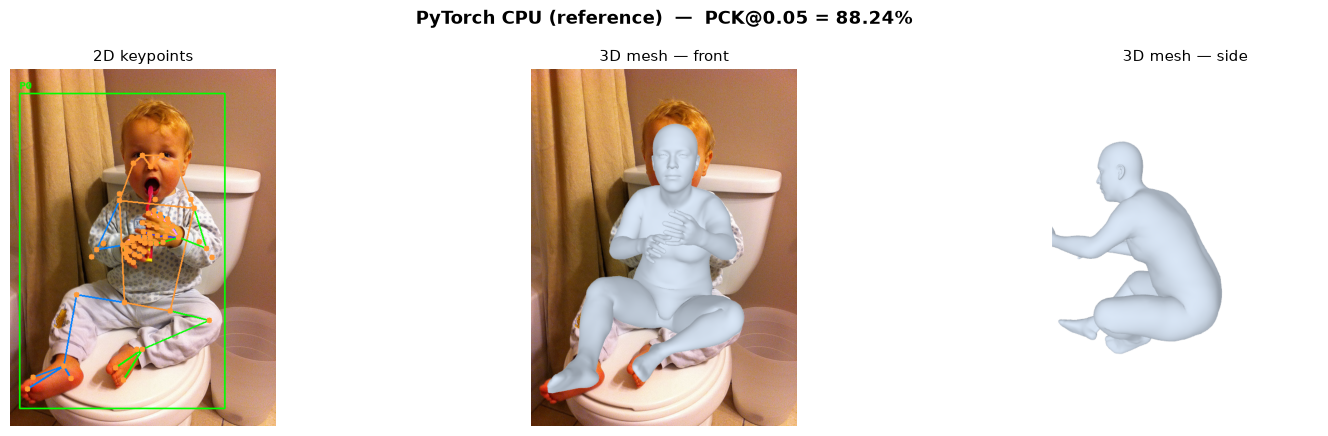

In [9]:
data.show_row(
    list(zip(["2D keypoints", "3D mesh — front", "3D mesh — side"], data.render_views(IMG_BGR, torch_person, MESH_FACES))),
    suptitle=f"{REFERENCE} (reference)  —  PCK@{PCK_THRESHOLD} = {torch_pck:.2f}%",
)

In [10]:
# Free the multi-GB PyTorch model before loading the OpenVINO pipelines.
# Predictions are already copied into RESULTS as plain NumPy.
del torch_model, outputs, pred
free_memory()
print("PyTorch model released.")

PyTorch model released.


## Convert the model to OpenVINO IR
[back to top ⬆️](#Table-of-contents:)

`sam3d_torch.py` traces each PyTorch sub-module with `torch.jit.trace` and
converts it with `ov.convert_model`. The pipeline uses several IRs rather
than one graph, because the decoder runs an *iterative MHR feedback loop* that
cannot be captured as a single static graph:

| Group | Contents |
|---|---|
| `backbone/` | DINOv3 ViT-H/16+ (ImageNet normalization baked in) |
| `iterative/` | 6 decoder layers, final norm, pose/camera heads, token MLPs |
| `iterative/` (aux) | `grid_sample`, `camera_projection`, `full_to_crop` — stateless ops |
| `mhr/` | dense mesh + skeleton head (`DenseMHR`, a sparse-op-free rewrite) |
| `mask_encoder/` | mask-conditioning CNN |
| `iterative/buffers/` | static `.npz` tensors (init pose, embeddings, PCA bases) |

Precision: `fp16` stores weights as FP16, `int8` applies NNCF weight-only
INT8 compression (`nncf.compress_weights`) and not post-training quantization — no calibration data is needed and
activations stay floating point.

In [11]:
import subprocess

from sam3d_ov import Sam3DBodyOpenVINO


def export_ir(precision):
    """Export the full pipeline to OpenVINO IR at `precision` (skips if present)."""
    out_dir = OV_MODEL_ROOT / precision
    if Sam3DBodyOpenVINO.is_available(out_dir, precision) and not FORCE_EXPORT:
        print(f"[skip] {precision.upper():5s} IR already complete at {out_dir}")
        return

    print(f"[export] {precision.upper()} -> {out_dir}  (several minutes)")
    subprocess.run(
        [
            sys.executable,
            str(NOTEBOOK_DIR / "sam3d_torch.py"),
            "--precision",
            precision,
            "--output_dir",
            str(OV_MODEL_ROOT),
            "--checkpoint",
            str(CHECKPOINT),
            "--mhr_path",
            str(MHR_PATH),
        ],
        check=True,
    )
    print(f"[export] {precision.upper()} done.")


for precision in PRECISIONS:
    export_ir(precision)

[skip] FP16  IR already complete at /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/ov_models/fp16
[skip] INT8  IR already complete at /home/naga/projects/sam3d-body/sam3d-body-nb/notebooks/ov_models/int8


In [12]:
# --- Report the on-disk footprint of each precision --------------------------
print(f"{'Precision':<10} {'Backbone':>12} {'MHR':>10} {'Total IR':>12}")
print("-" * 46)

IR_SIZES = {}
for precision in PRECISIONS:
    d = OV_MODEL_ROOT / precision
    total = sum(f.stat().st_size for f in d.rglob("*.bin")) / 1024**2
    total += sum(f.stat().st_size for f in d.rglob("*.xml")) / 1024**2
    backbone = (d / "backbone" / f"backbone_{precision}.bin").stat().st_size / 1024**2
    mhr = (d / "mhr" / f"mhr_{precision}.bin").stat().st_size / 1024**2
    IR_SIZES[precision] = total
    print(f"{precision.upper():<10} {backbone:>10.0f} MB {mhr:>8.0f} MB {total:>10.0f} MB")

if "fp16" in IR_SIZES and "int8" in IR_SIZES:
    print(f"\nINT8 is {IR_SIZES['fp16'] / IR_SIZES['int8']:.2f}x smaller than FP16 on disk.")

Precision      Backbone        MHR     Total IR
----------------------------------------------
FP16             1603 MB      338 MB       2053 MB
INT8              805 MB      195 MB       1066 MB

INT8 is 1.93x smaller than FP16 on disk.


## Run OpenVINO inference on Intel GPU
[back to top ⬆️](#Table-of-contents:)

`Sam3DBodyOpenVINO` reproduces the PyTorch pipeline and every heavy op
runs as an OpenVINO model on the GPU.

In [13]:
def run_openvino(precision, device=OV_DEVICE):
    """Compile the OV pipeline at `precision` and infer on the sample person."""
    print(f"\n=== OpenVINO {precision.upper()} on {device} ===")
    pipe = Sam3DBodyOpenVINO(OV_MODEL_ROOT / precision, device=device, precision=precision)
    pipe.warmup(n=1)  # JIT-compile kernels so the timing is steady-state

    t0 = time.perf_counter()
    out = pipe.infer_single(IMG_RGB, BBOX_XYXY, focal_length=FOCAL)
    latency_ms = (time.perf_counter() - t0) * 1000

    person = {
        "keypoints_2d": out["j2d"],  # [70, 2]
        "bbox": BBOX_XYXY,
        "vertices": out["verts"],  # [V, 3]
        "cam_t": out["cam_t"],
        "focal_length": out["focal_length"],
    }
    pck, correct, valid = compute_person_pck(person["keypoints_2d"], GT_ANN, PCK_THRESHOLD)

    print(f"Latency  : {latency_ms:8.1f} ms")
    print(f"PCK@{PCK_THRESHOLD} : {pck:8.2f} %   " f"({int(correct.sum())}/{int(valid.sum())} visible keypoints correct)")

    del pipe
    free_memory()
    return {"person": person, "keypoints": person["keypoints_2d"], "pck": pck, "latency_ms": latency_ms}


for precision in PRECISIONS:
    RESULTS[f"OpenVINO {precision.upper()}"] = run_openvino(precision)


=== OpenVINO FP16 on GPU ===
[Sam3DBodyOV] GPU INFERENCE_PRECISION_HINT = f16  (precision=fp16)
[Sam3DBodyOV] Loading backbone: backbone_fp16.xml
[Sam3DBodyOV] Loading MHR: mhr_fp16.xml
[Sam3DBodyOV] Loading 6 decoder layers and heads...
[Sam3DBodyOV] Loading buffers...
[Sam3DBodyOV] Ready. device=GPU precision=fp16
Latency  :    886.0 ms
PCK@0.05 :    82.35 %   (14/17 visible keypoints correct)

=== OpenVINO INT8 on GPU ===
[Sam3DBodyOV] GPU INFERENCE_PRECISION_HINT = f16  (precision=int8)
[Sam3DBodyOV] Loading backbone: backbone_int8.xml
[Sam3DBodyOV] Loading MHR: mhr_int8.xml
[Sam3DBodyOV] Loading 6 decoder layers and heads...
[Sam3DBodyOV] Loading buffers...
[Sam3DBodyOV] Ready. device=GPU precision=int8
Latency  :    806.2 ms
PCK@0.05 :    88.24 %   (15/17 visible keypoints correct)


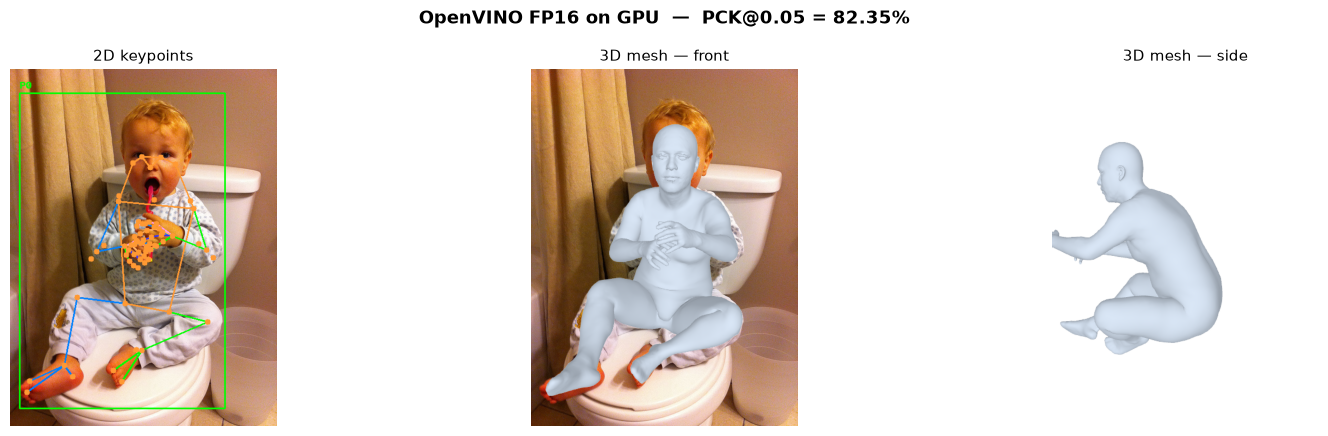

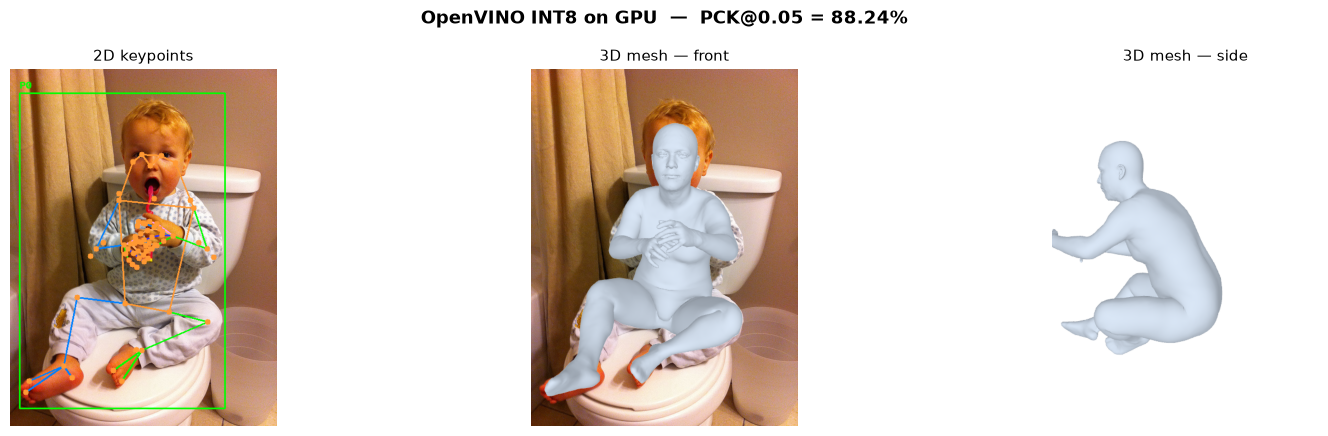

In [14]:
for name in [f"OpenVINO {p.upper()}" for p in PRECISIONS]:
    r = RESULTS[name]
    data.show_row(
        list(zip(["2D keypoints", "3D mesh — front", "3D mesh — side"], data.render_views(IMG_BGR, r["person"], MESH_FACES))),
        suptitle=f"{name} on {OV_DEVICE}  —  PCK@{PCK_THRESHOLD} = {r['pck']:.2f}%",
    )

## Compare PyTorch and OpenVINO
[back to top ⬆️](#Table-of-contents:)

1. **Visually** — skeletons and meshes side by side.
2. **Numerically** — PCK@0.05 metric for each backend.

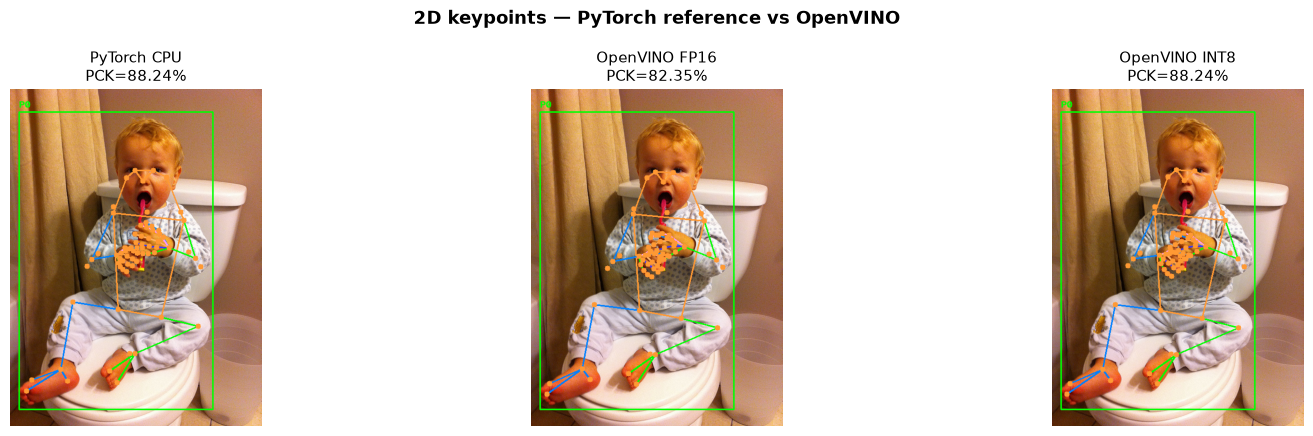

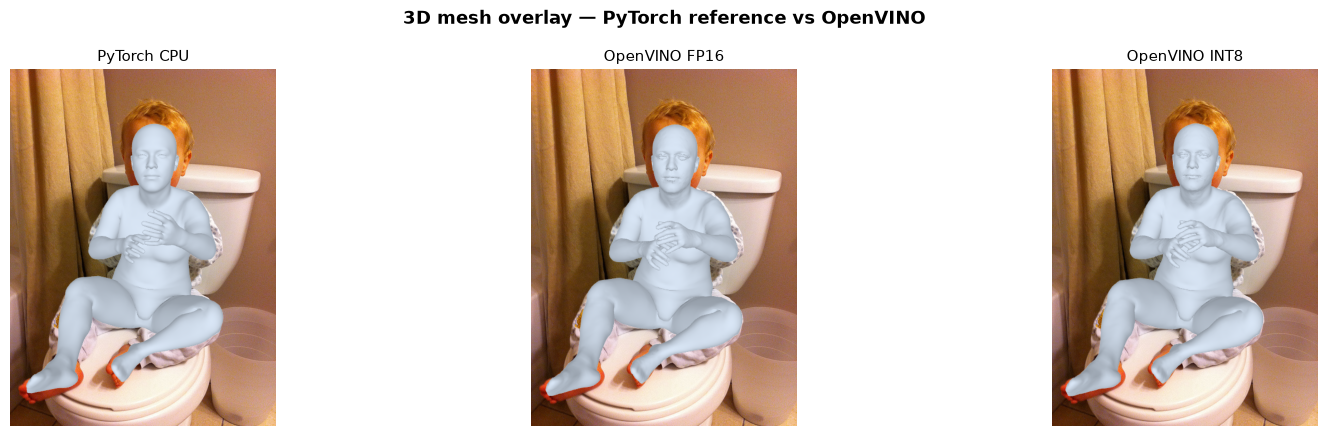

In [15]:
# --- Side-by-side skeletons ---------------------------------------------------
data.show_row(
    [(f"{name}\nPCK={r['pck']:.2f}%", data.render_views(IMG_BGR, r["person"], MESH_FACES)[0]) for name, r in RESULTS.items()],
    suptitle="2D keypoints — PyTorch reference vs OpenVINO",
)

# --- Side-by-side mesh overlays ----------------------------------------------
data.show_row(
    [(name, data.render_views(IMG_BGR, r["person"], MESH_FACES)[1]) for name, r in RESULTS.items()],
    suptitle="3D mesh overlay — PyTorch reference vs OpenVINO",
)

In [16]:
# --- Numerical agreement ------------------------------------------------------
ref_kpts = to_numpy(RESULTS[REFERENCE]["keypoints"])[COCO17_TO_MHR70]

# PCK tolerance in pixels: a deviation below this cannot flip a keypoint's verdict.
TOLERANCE_PX = data.pck_tolerance_px(GT_ANN["bbox"], PCK_THRESHOLD)


header = f"{'Backend':<18} {'PCK@0.05':>9} {'Latency':>10}"

print(header)
print("-" * len(header))

for name, r in RESULTS.items():
    kpts = to_numpy(r["keypoints"])[COCO17_TO_MHR70]
    dev = np.linalg.norm(kpts - ref_kpts, axis=-1)  # per-keypoint pixel error
    tag = "  (reference)" if name == REFERENCE else ""
    print(f"{name:<18} {r['pck']:>8.2f}% {r['latency_ms']:>8.0f}ms{tag}")

Backend             PCK@0.05    Latency
---------------------------------------
PyTorch CPU           88.24%     9730ms  (reference)
OpenVINO FP16         82.35%      886ms
OpenVINO INT8         88.24%      806ms


## Summary
[back to top ⬆️](#Table-of-contents:)

**What this notebook demonstrated**

1. The reference PyTorch SAM 3D Body model runs on a sample image on CPU or Intel XPU (if chosen).
2. The pipeline converts to OpenVINO IR at FP16 and INT8.
3. Both IRs run on the **Intel GPU** and produce
   keypoints that agree with PyTorch (measured via the PCK@0.05 metric), and the meshes produced are visually indistinguishable.


**Running on your own image.** `data.make_sample()` turns any image plus a COCO-style
annotation into the dict used above.

```python
import cv2, sam3d_data as data
from sam3d_ov import Sam3DBodyOpenVINO

pipe = Sam3DBodyOpenVINO(OV_MODEL_ROOT / "fp16", device="GPU", precision="fp16")
pipe.warmup()

sample = data.make_sample(cv2.imread("my_photo.jpg"),
                          {"bbox": [x, y, w, h], "keypoints": [0] * 51})
out = pipe.infer_single(sample["img_rgb"], sample["bbox_xyxy"],
                        focal_length=sample["focal_length"])
person = {"keypoints_2d": out["j2d"], "bbox": sample["bbox_xyxy"]}
data.show_row([("prediction", data.render_views(sample["img_bgr"], person, None)[0])])
```

**Useful links**

- [SAM 3D Body](https://github.com/facebookresearch/sam-3d-body)
- [OpenVINO documentation](https://docs.openvino.ai/)
- [OpenVINO notebooks](https://github.com/openvinotoolkit/openvino_notebooks)